<a href="https://colab.research.google.com/github/NK47GG/shoes-image-similarity-autoencoder/blob/main/Casual_Shoes_Image_Similarity_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Setup: Kerja Langsung dari File ZIP
Bagian ini digunakan jika kamu ingin menjalankan notebook menggunakan file `.zip` gambar dan `.csv` yang sudah didownload sebelumnya.

In [ ]:
import zipfile
import os
import pandas as pd

# 1. Make sure casual_shoes_data.csv and casual_shoes_images_dataset.zip exist in /content/
csv_path = 'casual_shoes_data.csv'
zip_path = 'casual_shoes_images_dataset.zip'
extract_dir = 'extracted_casual_shoes'

if os.path.exists(zip_path) and os.path.exists(csv_path):
    # Extract images
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # Load DataFrame
    shoes = pd.read_csv(csv_path)

    # Point filepath to the extracted folder
    shoes['filepath'] = shoes['id'].apply(lambda x: os.path.join(os.getcwd(), extract_dir, f"{x}.jpg"))

    print(f"\u2705 Setup successful!")
    print(f"Total records: {len(shoes)}")
    print(f"Image folder: {extract_dir}")
else:
    print("⚠️ ZIP or CSV file not found. Make sure you have uploaded them to /content/")


✅ Setup successful!
Total records: 2845
Image folder: extracted_casual_shoes


# Casual Shoes Image Similarity Search
**Architecture**: Pretrained CNN Feature Extractor (VGG16 · ResNet50)  
**Dataset**: `paramaggarwal/fashion-product-images-dataset` → **filter: Casual Shoes only**

---
## Ringkasan Pipeline

| # | Tahap | Keterangan |
|---|---|---|
| 1 | Data Collection | Download & merge styles + images CSV |
| 2 | Filter Casual Shoes | `articleType == 'Casual Shoes'` |
| 3 | Pretrained Feature Extractor | VGG16 · ResNet50 (tanpa Decoder, tanpa training) |
| 4 | Feature Extraction | Embeddings seluruh gambar Casual Shoes |
| 5 | Similarity Functions | Cosine Similarity |
| 6 | Visualisasi Hasil | Gambar + label nama file + skor, per metric |
| 7 | DCG / NDCG / Recall Manual | Evaluasi manual |
| 8 | Evaluasi | 2 model × 1 metric → Recall@5/10, NDCG@5/10 |
| 9 | Gradio Interface | Upload gambar → top-K hasil dengan gambar & label |


## 0. Environment Setup

In [ ]:
!pip install kagglehub gradio tensorflow seaborn --quiet

import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import PIL.Image
import gradio as gr

import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16        import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50     import preprocess_input as res_pre
from tensorflow.keras.preprocessing.image       import load_img, img_to_array
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

IMG_SIZE   = (224, 224)
BATCH_SIZE = 64

print(f"TensorFlow : {tf.__version__}")
print(f"Gradio     : {gr.__version__}")


TensorFlow : 2.20.0
Gradio     : 5.50.0


## 1. Data Collection & Filter Casual Shoes

- Download dataset dari Kaggle
- Merge `styles.csv` + `images.csv` berdasarkan `id`
- Filter hanya `articleType == 'Casual Shoes'`
- Kolom `item_label` dibuat dari **nama file tanpa ekstensi** → dipakai sebagai label display


In [ ]:
# import kagglehub
# dataset_path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")
# print("Dataset path:", dataset_path)
print("✓ Skipping Kaggle download, using local ZIP file.")


✓ Skipping Kaggle download, using local ZIP file.


In [ ]:
# images_dir = os.path.join(dataset_path, "fashion-dataset", "images")
# images_df = pd.read_csv(os.path.join(dataset_path, "fashion-dataset", "images.csv"))
# ... (Kaggle Data Collection logic is commented out)

# Directly use the 'shoes' DataFrame already loaded in the Setup cell above
print(f"Total Casual Shoes loaded from ZIP: {len(shoes):,}")
print()
print("Sample data:")
display(shoes[["id","item_label","gender","baseColour","articleType"]].head(8))


Total Casual Shoes loaded from ZIP: 2,845

Sample data:


,id,item_label,gender,baseColour,articleType
0,9204,9204,Men,Black,Casual Shoes
1,39988,39988,Men,White,Casual Shoes
2,22198,22198,Men,Black,Casual Shoes
3,29570,29570,Men,Purple,Casual Shoes
4,26538,26538,Men,Red,Casual Shoes
5,49495,49495,Men,Khaki,Casual Shoes
6,19311,19311,Men,White,Casual Shoes
7,49461,49461,Men,Blue,Casual Shoes


In [ ]:
shoes.to_csv("casual_shoes_data.csv", index=False)
print("casual_shoes_data.csv has been saved.")

casual_shoes_data.csv has been saved.


## 1.1. Data Splitting (Train, Validation, Test)

Meskipun menggunakan *pretrained models*, membagi dataset adalah praktik terbaik untuk memastikan evaluasi dilakukan pada data yang tidak digunakan dalam proses pengembangan sistem.

In [ ]:
from sklearn.model_selection import train_test_split

# Split 1: Separate Train (80%) and the rest (20% for Val + Test)
shoes_train, shoes_temp = train_test_split(
    shoes,
    test_size=0.20,
    random_state=42,
    stratify=shoes['gender'] if 'gender' in shoes.columns else None
)

# Split 2: Divide the remaining 20% into Validation (10%) and Test (10%)
# Since 10% is half of 20%, we use test_size=0.5
shoes_val, shoes_test = train_test_split(
    shoes_temp,
    test_size=0.50,
    random_state=42
)

print(f"📊 Splitting Results:")
print(f"  • Total Data  : {len(shoes)}")
print(f"  • Training    : {len(shoes_train)} (80%)")
print(f"  • Validation  : {len(shoes_val)} (10%)")
print(f"  • Testing     : {len(shoes_test)} (10%)")


📊 Splitting Results:
  • Total Data  : 2845
  • Training    : 2276 (80%)
  • Validation  : 284 (10%)
  • Testing     : 285 (10%)


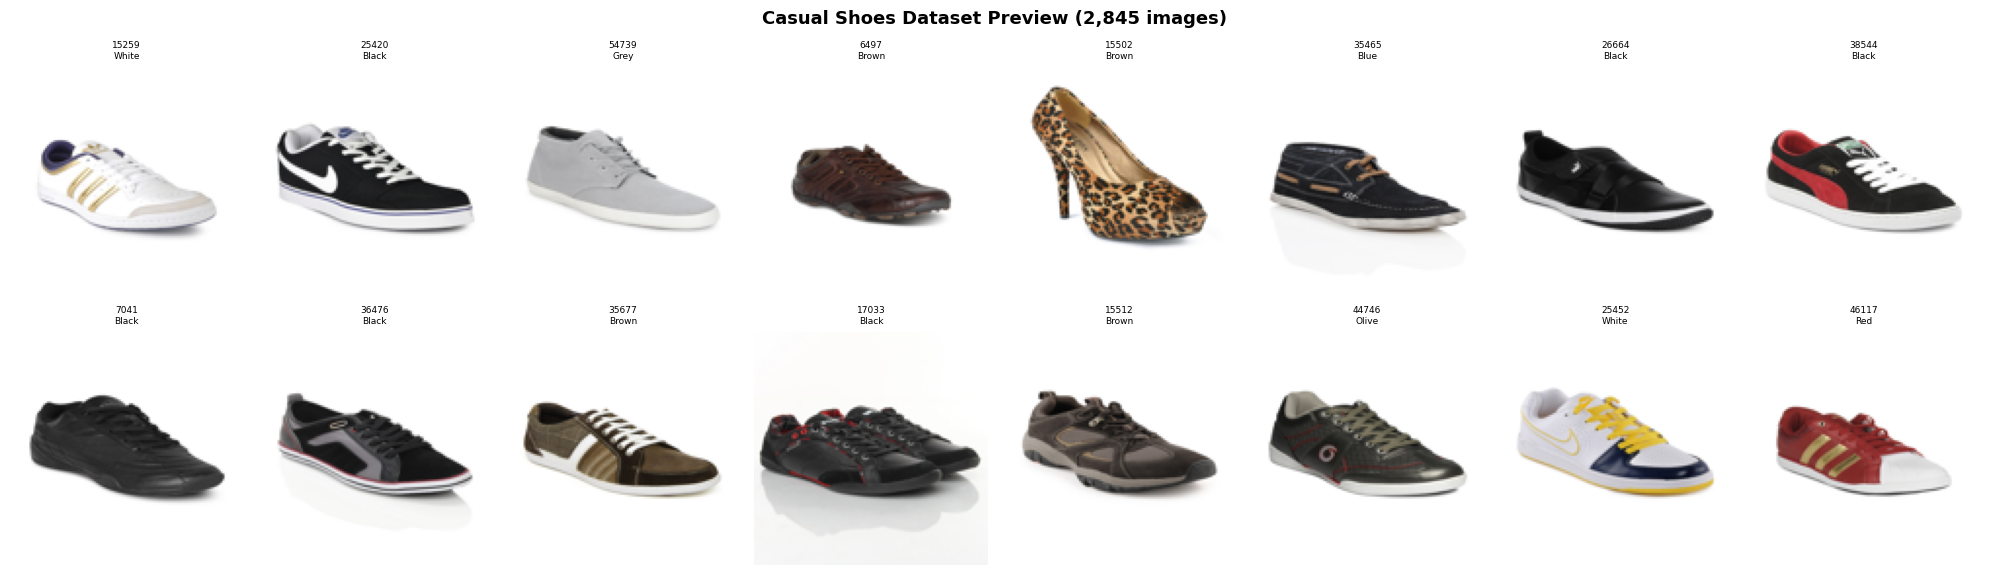

In [ ]:
# ── Preview Casual Shoes images ───────────────────────────────────────────────
sample_preview = shoes.sample(16, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for ax, (_, row) in zip(axes.flatten(), sample_preview.iterrows()):
    try:
        img = PIL.Image.open(row["filepath"]).resize((120, 120))
        ax.imshow(img)
    except Exception:
        ax.set_facecolor("#eee")
    ax.set_title(f"{row['item_label']}\n{row.get('baseColour','')}", fontsize=6.5)
    ax.axis("off")

plt.suptitle(f"Casual Shoes Dataset Preview ({len(shoes):,} images)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("casual_shoes_preview.png", dpi=130, bbox_inches="tight")
plt.show()


## 2. Pretrained Feature Extractor — Tanpa Decoder, Tanpa Training

Tiga model dari `keras.applications` — semua weight pretrained ImageNet.  
`include_top=False, pooling='avg'` → langsung menghasilkan feature vector.

| Model | Output Dim | Params |
|---|---|---|
| VGG16 | 512 | ~14.7M |
| ResNet50 | 2048 | ~23.5M |


In [ ]:
def build_extractor(name):
    kw = dict(weights="imagenet", include_top=False,
               pooling="avg", input_shape=(224, 224, 3))
    if name == "VGG16":
        m, fn = VGG16(**kw),       vgg_pre
    elif name == "ResNet50":
        m, fn = ResNet50(**kw),     res_pre
    else:
        raise ValueError(name)
    m.trainable = False
    return m, fn

models_dict = {}
for mname in ["VGG16", "ResNet50"]:
    m, fn = build_extractor(mname)
    models_dict[mname] = {"model": m, "preprocess": fn}
    print(f"✓ {mname:15s} | dim={m.output_shape[-1]:>5d} | params={m.count_params():,}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ VGG16           | dim=  512 | params=14,714,688
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ ResNet50        | dim= 2048 | params=23,587,712


## 3. Feature Extraction — Embeddings Seluruh Casual Shoes

In [ ]:
def extract_embeddings(df, model, prep_fn, img_size=IMG_SIZE, batch=BATCH_SIZE):
    all_embs, valid_idx = [], []
    for start in range(0, len(df), batch):
        chunk = df.iloc[start:start+batch]
        arrs, idxs = [], []
        for idx, row in chunk.iterrows():
            try:
                arr = img_to_array(load_img(row["filepath"], target_size=img_size))
                arrs.append(prep_fn(arr))
                idxs.append(idx)
            except Exception:
                continue
        if arrs:
            embs = model.predict(np.array(arrs), verbose=0)
            all_embs.extend(embs)
            valid_idx.extend(idxs)
        done = min(start + batch, len(df))
        print(f"  {done}/{len(df)}", end="\r")
    return np.array(all_embs), valid_idx

databases = {}
print(f"Extracting embeddings from {len(shoes_train):,} Training images\n")

for mname, info in models_dict.items():
    print(f"[{mname}]")
    embs, vidx = extract_embeddings(shoes_train, info["model"], info["preprocess"])
    vdf = shoes_train.loc[vidx].reset_index(drop=True)
    databases[mname] = {"embeddings": embs, "metadata": vdf}
    joblib.dump(databases[mname], f"db_{mname.lower()}.pkl")
    print(f"  ✓ embeddings shape = {embs.shape}\n")


Extracting embeddings from 2,276 Training images

[VGG16]
  ✓ embeddings shape = (2276, 512)

[ResNet50]
  ✓ embeddings shape = (2276, 2048)



## 4. Similarity Functions

| Metric | Cara Kerja | Skor tinggi = makin mirip |
|---|---|---|
| **Cosine Similarity** | Sudut antar vektor | ✓ |

> Cosine = 1.0 (item identik / diri sendiri) **dikecualikan** dari hasil, tapi top-K tetap penuh.


In [ ]:
def cosine_scores(q, db):
    return sk_cosine(q.reshape(1, -1), db)[0]

    return -np.sqrt(((db - q) ** 2).sum(axis=1))

    return -np.abs(db - q).sum(axis=1)

    q_c = q - q.mean()
    q_s = q.std()
    d_c = db - db.mean(axis=1, keepdims=True)
    d_s = db.std(axis=1)
    if q_s == 0:
        return np.full(len(db), -1.)
    with np.errstate(invalid="ignore", divide="ignore"):
        r = (d_c * q_c).mean(axis=1) / (d_s * q_s + 1e-9)
    return np.nan_to_num(r, nan=-1.)

SIM_FNS = {
    "Cosine Similarity"              : cosine_scores,
            }
SIM_SHORT = {
    "Cosine Similarity"              : "Cosine",
            }
print("Similarity functions ready:", list(SIM_FNS.keys()))


Similarity functions ready: ['Cosine Similarity']


## 5. Retrieval Helper

In [ ]:
def prep_query(src, prep_fn, img_size=IMG_SIZE):
    """Path string or PIL.Image → preprocessed tensor (1,H,W,3)."""
    if isinstance(src, str):
        arr = img_to_array(load_img(src, target_size=img_size))
    else:
        img = src.resize(img_size)
        arr = np.array(img)
        if arr.ndim == 2:
            arr = np.stack([arr]*3, axis=-1)
        elif arr.shape[-1] == 4:
            arr = arr[:, :, :3]
        arr = arr.astype("float32")
    return prep_fn(arr)[np.newaxis]

def retrieve(query_emb, query_id, db, sim_fn, top_k=10):
    """
    Return top-K DataFrame + all scores.
    - Items with the same id as the query are excluded (including cosine=1.0 cases).
    - top_k=5 or top_k=10 are always returned in full.
    """
    embs, meta = db["embeddings"], db["metadata"]
    scores     = sim_fn(query_emb, embs)
    idx        = np.argsort(scores)[::-1]

    if query_id is not None:
        idx = [i for i in idx if meta.iloc[i]["id"] != query_id]

    top    = list(idx[:top_k])
    res    = meta.iloc[top].copy().reset_index(drop=True)
    res["score"] = scores[np.array(top)]
    return res, scores


## 6. Visualisasi Similarity — Gambar + Label Nama File

Untuk satu query, semua 4 metric ditampilkan sekaligus dalam satu figure:
- **Setiap baris** = 1 similarity metric
- **Setiap kolom** = 1 hasil (top-5)
- Setiap thumbnail dilengkapi:
  - **Nama file** (item_label = ID produk dari nama file)
  - **Warna & gender**
  - **Skor similarity**
  - Border **hijau** di rank #1


In [ ]:
def visualize_similarity(query_src, model_name, top_k=5, save_path=None):
    """
    Visualization grid: 4 metrics (rows) × top_k results (columns).
    Leftmost column = query image.
    Each thumbnail: image + item_label + score.
    """
    info  = models_dict[model_name]
    db    = databases[model_name]

    # Embed query
    q_arr = prep_query(query_src, info["preprocess"])
    q_emb = info["model"].predict(q_arr, verbose=0)[0]

    # Query ID for exclusion
    if isinstance(query_src, str):
        try:
            qid = int(os.path.splitext(os.path.basename(query_src))[0])
        except ValueError:
            qid = None
    else:
        qid = None

    n_metric = len(SIM_FNS)
    fig, axes = plt.subplots(
        n_metric, top_k + 1,
        figsize=((top_k + 1) * 2.6, n_metric * 3.4),
        squeeze=False # Added squeeze=False to ensure axes is always a 2D array
    )

    # ── Query image (column 0) ────────────────────────────────────────────────
    try:
        q_pil = PIL.Image.open(query_src) if isinstance(query_src, str) else query_src
        q_pil = q_pil.resize((180, 180))
    except Exception:
        q_pil = PIL.Image.new("RGB", (180, 180), (220, 220, 220))

    # Show query label only on first row; leave other rows blank
    if isinstance(query_src, str):
        q_label = os.path.splitext(os.path.basename(query_src))[0]
    else:
        q_label = "query"

    for row_i in range(n_metric):
        ax0 = axes[row_i][0]
        ax0.imshow(q_pil)
        if row_i == 0:
            ax0.set_title(f"QUERY\n{q_label}", fontsize=8,
                           fontweight="bold", color="navy")
        else:
            ax0.set_title("", fontsize=8)
        ax0.axis("off")

        # Metric label on left side
        sim_name = list(SIM_FNS.keys())[row_i]
        ax0.set_ylabel(
            SIM_SHORT[sim_name], fontsize=9, fontweight="bold",
            rotation=0, labelpad=52, va="center", color="#8B0000"
        )

    # ── Similarity results per metric ─────────────────────────────────────────
    for row_i, (sim_name, sim_fn) in enumerate(SIM_FNS.items()):
        res_df, _ = retrieve(q_emb, qid, db, sim_fn, top_k=top_k)

        for col_i, (_, rrow) in enumerate(res_df.iterrows()):
            ax = axes[row_i][col_i + 1]

            # Image
            try:
                img = PIL.Image.open(rrow["filepath"]).resize((180, 180))
                ax.imshow(img)
            except Exception:
                ax.set_facecolor("#ddd")
                ax.text(0.5, 0.5, "err", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8)

            # Label: filename + color + gender + score
            colour = rrow.get("baseColour", "")
            gender = rrow.get("gender", "")
            title  = (f"#{col_i+1}  {rrow['item_label']}\n"
                      f"{colour} · {gender}\n"
                      f"score: {rrow['score']:.4f}")
            ax.set_title(title, fontsize=6.8, pad=3, linespacing=1.4)
            ax.axis("off")

            # Green border for rank #1, grey for others
            border_color = "#2ca02c" if col_i == 0 else "#cccccc"
            border_width = 2.5      if col_i == 0 else 0.8
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border_color)
                spine.set_linewidth(border_width)

    plt.suptitle(
        f"Top-{top_k} Casual Shoes Similarity — Model: {model_name}\n"
        f"Label = filename (product ID)  |  identical items excluded",
        fontsize=11, fontweight="bold", y=1.01
    )
    plt.tight_layout()

    fname = save_path or f"sim_{model_name.lower()}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()
    return fname

Query: 22874 | Black | Men


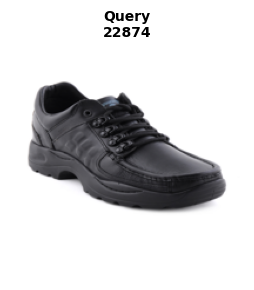


--- VGG16 ---


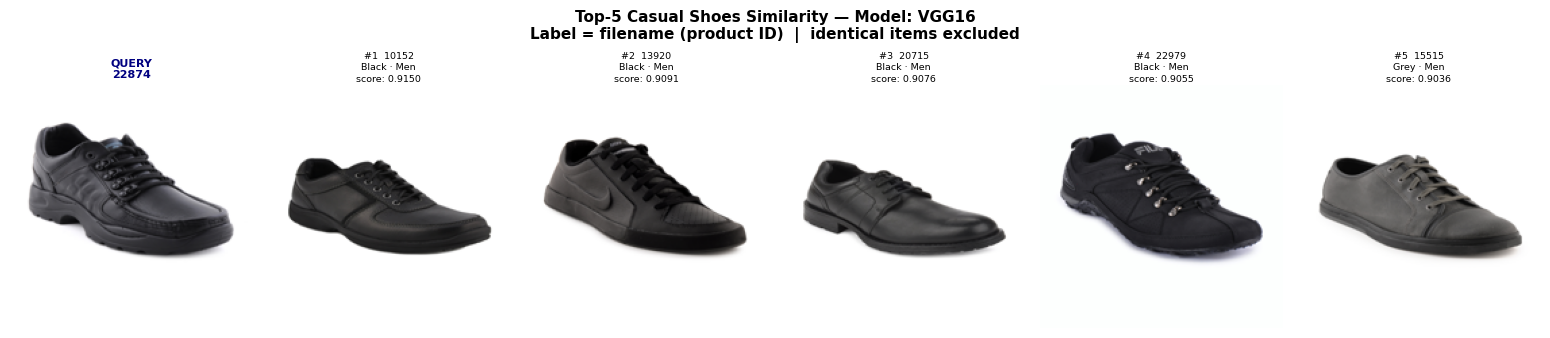


--- ResNet50 ---


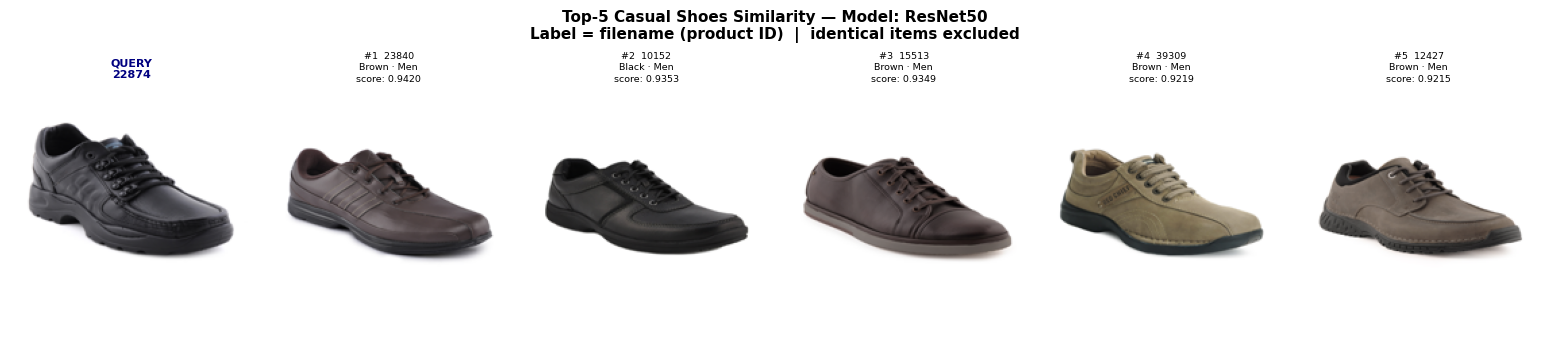

In [ ]:
# ── Demo: one query → display 3 models × 4 metrics ──────────────────────────
sample_row = shoes.sample(1, random_state=77).iloc[0]
query_path = sample_row["filepath"]

print(f"Query: {sample_row['item_label']} | "
      f"{sample_row.get('baseColour','')} | {sample_row.get('gender','')}")

# Display query image
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(PIL.Image.open(query_path).resize((200, 200)))
ax.set_title(f"Query\n{sample_row['item_label']}", fontweight="bold", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

# Visualize per model
result_fnames = {}
for mname in ["VGG16", "ResNet50"]:
    print(f"\n--- {mname} ---")
    fname = visualize_similarity(query_path, mname, top_k=5,
                                  save_path=f"sim_{mname.lower()}.png")
    result_fnames[mname] = fname


## 7. MRR — Mean Reciprocal Rank dengan Human Judgment

**Mean Reciprocal Rank (MRR)** mengukur seberapa tinggi posisi hasil yang **paling relevan**:

```
RR  = 1 / rank_gambar_terpilih   (0 jika gambar terpilih tidak ada di top-K)
MRR = (1/|Q|) × Σ RR_i
```

### Cara Kerja

1. **Pilih rentang data test** — misal gambar nomor 1 sampai 100 (bisa diubah bebas, sesuai jumlah data yang tersedia).
2. Untuk setiap gambar dalam rentang itu, sistem menampilkan **pool gambar kandidat** (gabungan top-5 dari 2 model × 1 metric = 2 kombinasi, dideduplikasi).
3. Annotator **klik satu gambar** yang paling sesuai/mirip dengan query — sistem langsung lanjut ke query berikutnya (tidak ada checkbox, tidak perlu tombol simpan terpisah).
4. Setiap klik **langsung disimpan ke file Excel lokal** — jika Colab disconnect di tengah jalan, progres tidak hilang; jalankan ulang dan sistem otomatis lanjut dari yang belum dipilih.
5. MRR dihitung dari posisi gambar pilihanmu di tiap 2 kombinasi, lalu hasilnya juga ditulis ke Excel.

### Isi File Excel (`mrr_annotations.xlsx`)

| Sheet | Isi |
|---|---|
| `Info` | Total data test, rentang yang dipilih, jumlah pool per query |
| `Anotasi` | List data dari nomor awal–akhir + gambar yang dipilih sebagai paling cocok |
| `MRR_Summary` | MRR untuk 2 kombinasi model × metric |

In [ ]:
# ── Setup ──────────────────────────────────────────────────────────────────────
!pip install openpyxl --quiet

import io as _io, os as _os
import pandas as pd
import numpy as np

EXCEL_PATH = "/content/mrr_annotations.xlsx"   # annotation Excel output file

MODEL_NAMES = ["VGG16", "ResNet50"]
TOP_K_POOL  = 5     # top-K from each combination merged into the pool

# ── Total test data ────────────────────────────────────────────────────────────
# Fix: reference shoes_test (not the full dataset)
TOTAL_DATA_TEST = len(shoes_test)
print(f"📊 Total test data (Casual Shoes) : {TOTAL_DATA_TEST:,} images")
print(f"   Valid index range               : 1 – {TOTAL_DATA_TEST}")

# ── MRR helper functions ────────────────────────────────────────────────────────
def reciprocal_rank(ranked_ids, chosen_id):
    """RR = 1/rank of the chosen image; 0 if not found in ranked_ids."""
    for rank, rid in enumerate(ranked_ids, start=1):
        if rid == chosen_id:
            return 1.0 / rank
    return 0.0

def compute_mrr(rr_list):
    return float(np.mean(rr_list)) if rr_list else 0.0

print("\n✓ Helper functions ready.")


📊 Total test data (Casual Shoes) : 285 images
   Valid index range               : 1 – 285

✓ Helper functions ready.


## 8. Pilih Rentang Data Test

Edit `START_NO` dan `END_NO` di bawah — keduanya **1-based** (artinya `START_NO = 1` berarti data pertama).

Contoh: ingin menghitung MRR dari gambar **1 sampai 100** → `START_NO = 1`, `END_NO = 100`.

In [ ]:
# Use shoes_test as the query source for evaluation
START_NO = 1
END_NO   = min(285, len(shoes_test)) # Evaluate the first 10 samples from the Test set

target_positions = list(range(START_NO - 1, END_NO))
eval_query_rows  = shoes_test.iloc[target_positions].reset_index(drop=True)
N_QUERIES        = len(eval_query_rows)

print(f"Total Test data      : {len(shoes_test):,} images")
print(f"Evaluation Range     : records {START_NO} to {END_NO} from Test Set")
print(f"Number of Queries    : {N_QUERIES}")


Total Test data      : 285 images
Evaluation Range     : records 1 to 285 from Test Set
Number of Queries    : 285


In [ ]:
# ── Pre-compute: embedding + retrieval for the selected range ─────────────────
retrieval_cache = {}   # {(mname, sname, q_idx): list of item dict}

print(f"Pre-computing retrieval for {N_QUERIES} queries × "
      f"{len(MODEL_NAMES) * len(SIM_FNS)} combinations...\n")

for q_idx, qrow in eval_query_rows.iterrows():
    for mname in MODEL_NAMES:
        info  = models_dict[mname]
        db    = databases[mname]
        q_emb = info["model"].predict(
            prep_query(qrow["filepath"], info["preprocess"]), verbose=0
        )[0]
        for sname, sfn in SIM_FNS.items():
            res_df, _ = retrieve(q_emb, int(qrow["id"]), db, sfn, top_k=TOP_K_POOL)
            retrieval_cache[(mname, sname, q_idx)] = [
                {
                    "id"      : int(row["id"]),
                    "filepath": row["filepath"],
                    "label"   : row["item_label"],
                    "colour"  : row.get("baseColour", ""),
                    "gender"  : row.get("gender", ""),
                }
                for _, row in res_df.iterrows()
            ]
    print(f"  Query {q_idx+1:3d}/{N_QUERIES} (record {START_NO + q_idx}) done", end="\r")

# ── Build unique pool per query ────────────────────────────────────────────────
query_pools = {}
for q_idx in range(N_QUERIES):
    seen, pool = set(), []
    for mname in MODEL_NAMES:
        for sname in SIM_FNS:
            for item in retrieval_cache[(mname, sname, q_idx)]:
                if item["id"] not in seen:
                    seen.add(item["id"])
                    pool.append(item)
    query_pools[q_idx] = pool

print(f"\n\n✓ Pre-compute done for {N_QUERIES} queries.")
print(f"  Average pool size: "
      f"{np.mean([len(p) for p in query_pools.values()]):.1f} images/query")


Pre-computing retrieval for 285 queries × 2 combinations...

  Query 285/285 (record 285) done

✓ Pre-compute done for 285 queries.
  Average pool size: 8.6 images/query


## 9. Sesi Pemilihan — Klik Satu Gambar Paling Cocok

Untuk setiap query: klik **satu gambar** di pool yang paling mirip/sesuai dengan gambar query.  
Sistem langsung **menyimpan ke Excel** dan **lanjut ke query berikutnya** — tidak perlu tombol simpan.

Kalau memang tidak ada gambar yang cocok sama sekali, klik **"Tidak ada yang cocok"** (RR untuk query itu otomatis dihitung 0).

> Jika Colab disconnect di tengah jalan: jalankan ulang notebook dari cell pre-compute, lalu jalankan cell widget ini lagi — sistem otomatis skip query yang sudah kamu pilih sebelumnya (dibaca dari `mrr_annotations.xlsx`).

In [ ]:
# ── Single-Click Widget + Auto-save to Excel ──────────────────────────────────
import os as _os
import io as _io
import pandas as pd
import PIL.Image
from PIL import ImageOps
import ipywidgets as widgets
from IPython.display import display, clear_output, Javascript   # ← tambah Javascript

# ── Resume: read existing choices ─────────────────────────────────────────────
def load_existing_choices():
    if not _os.path.exists(EXCEL_PATH):
        return {}
    try:
        df = pd.read_excel(EXCEL_PATH, sheet_name="Annotation")
    except Exception:
        return {}
    out = {}
    for _, row in df.iterrows():
        no_data = int(row["No_Data"])
        q_idx   = no_data - START_NO
        if 0 <= q_idx < N_QUERIES and pd.notna(row["Selected_Image_ID"]):
            out[q_idx] = int(row["Selected_Image_ID"])
    return out

human_choices = load_existing_choices()
_done = set(human_choices.keys())
_todo = [q for q in range(N_QUERIES) if q not in _done]

print(f"Previously selected  : {len(_done)} / {N_QUERIES} queries")
print(f"Remaining            : {len(_todo)} queries")

# ── Save to Excel ──────────────────────────────────────────────────────────────
def save_annotation_to_excel():
    rows = []
    for q_idx in range(N_QUERIES):
        qrow   = eval_query_rows.iloc[q_idx]
        chosen = human_choices.get(q_idx, None)
        rows.append({
            "No_Data"           : START_NO + q_idx,
            "Query_ID"          : int(qrow["id"]),
            "Filename_Query"    : qrow["item_label"],
            "Selected_Image_ID" : chosen if chosen is not None else None,
            "Status"            : (
                "Not selected" if chosen is None
                else ("No match" if chosen == -1 else "Selected")
            ),
        })
    df   = pd.DataFrame(rows)
    mode = "a" if _os.path.exists(EXCEL_PATH) else "w"
    kw   = {"if_sheet_exists": "replace"} if mode == "a" else {}
    with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl", mode=mode, **kw) as writer:
        df.to_excel(writer, sheet_name="Annotation", index=False)

# ── Helper: re-run cell ini secara otomatis ────────────────────────────────────
def _rerun_this_cell():
    display(Javascript("""
        (function() {
            // Classic Jupyter Notebook
            if (typeof Jupyter !== 'undefined' && Jupyter.notebook) {
                Jupyter.notebook.execute_cell();
                return;
            }
            // JupyterLab / VS Code / modern env
            const tryLab = () => {
                const app = window.jupyterapp || window.app;
                if (app && app.commands) {
                    app.commands.execute('notebook:run-cell');
                }
            };
            setTimeout(tryLab, 100);
        })();
    """))

# ── Widget ─────────────────────────────────────────────────────────────────────
if not _todo:
    print("\n✅ All queries in this range have been selected! Proceed to MRR calculation below.")
else:
    def _img_bytes(path, size=(128, 128)):
        try:
            img = PIL.Image.open(path).convert("RGB")
            img = ImageOps.pad(img, size, color=(255, 255, 255))
        except Exception:
            img = PIL.Image.new("RGB", size, (240, 240, 240))
        buf = _io.BytesIO()
        img.save(buf, format="JPEG", quality=90)
        return buf.getvalue()

    _state           = {"todo_pos": 0, "picking": False}
    _current_buttons = []
    main_out         = widgets.Output()

    def _disable_all_buttons():
        for btn in _current_buttons:
            btn.disabled = True
        _current_buttons.clear()

    def _make_pick_card(item):
        btn = widgets.Button(
            description="✅ Select",
            button_style="success",
            layout=widgets.Layout(width="100%", margin="5px 0 0 0")
        )
        _current_buttons.append(btn)
        btn.on_click(lambda b, iid=item["id"]: _on_pick(iid))
        return widgets.VBox([
            widgets.Image(value=_img_bytes(item["filepath"], (120, 120)),
                          format='jpeg', width=120, height=120),
            widgets.HTML(
                f"<div style='text-align:center;height:20px;overflow:hidden;'>"
                f"<small style='color:#4B5563;'>{item['label']}</small></div>"
            ),
            btn,
        ], layout=widgets.Layout(
            border="1px solid #E5E7EB", border_radius="8px",
            align_items="center", padding="8px", background_color="#FFFFFF"
        ))

    def _make_skip_card():
        btn = widgets.Button(
            description="🚫 No\nmatch", button_style="danger",
            layout=widgets.Layout(width="110px", height="110px", margin="0 0 0 20px")
        )
        _current_buttons.append(btn)
        btn.on_click(lambda b: _on_pick(-1))
        return btn

    def _render():
        _current_buttons.clear()

        pos   = _state["todo_pos"]
        q_idx = _todo[pos]
        qrow  = eval_query_rows.iloc[q_idx]
        pool  = query_pools[q_idx][:10]

        done_total = len(_done) + pos
        pct        = int(done_total / N_QUERIES * 100)

        hdr_html = widgets.HTML(
            f"<h3 style='margin:4px 0;color:#111827;'>🏷️ Record {START_NO + q_idx}</h3>"
            f"<p style='color:#4B5563;margin:2px 0;font-size:14px;'>"
            f"Click one image from <b>Top 10 Nearest</b>.</p>"
            f"<div style='width:100%;max-width:400px;background:#E5E7EB;"
            f"border-radius:6px;margin-top:8px;'>"
            f"<div style='width:{pct}%;background:#10B981;height:8px;"
            f"border-radius:6px;transition:width 0.3s;'></div></div>"
        )

        qimg_box = widgets.VBox([
            widgets.Image(value=_img_bytes(qrow["filepath"], (180, 180)),
                          format='jpeg', width=180, height=180),
            widgets.HTML(
                f"<div style='text-align:center;padding-top:8px;'>"
                f"<b style='color:#111827;'>Query Image</b><br>"
                f"<span style='color:#6B7280;font-size:12px;'>{qrow['item_label']}</span></div>"
            ),
        ], layout=widgets.Layout(
            margin='10px', padding='15px',
            border='1px solid #D1D5DB', border_radius='8px',
            background_color='#F9FAFB'
        ))

        cards    = [_make_pick_card(item) for item in pool]
        grid     = widgets.GridBox(cards, layout=widgets.Layout(
            grid_template_columns="repeat(5, 150px)",
            grid_template_rows="repeat(2, auto)",
            gap="12px"
        ))
        pool_box = widgets.HBox(
            [grid, _make_skip_card()],
            layout=widgets.Layout(align_items='center')
        )

        with main_out:
            clear_output(wait=True)
            display(hdr_html)
            display(widgets.HBox(
                [qimg_box, pool_box],
                layout=widgets.Layout(align_items='flex-start')
            ))

    def _on_pick(chosen_id):
        if _state["picking"]:
            return
        _state["picking"] = True

        # 1. Matikan semua tombol seketika
        _disable_all_buttons()

        # 2. Simpan pilihan ke memori + Excel
        q_idx = _todo[_state["todo_pos"]]
        human_choices[q_idx] = chosen_id
        _done.add(q_idx)
        save_annotation_to_excel()

        _state["picking"] = False

        # 3. Tampilkan pesan loading sebelum cell re-run
        with main_out:
            clear_output(wait=True)
            display(widgets.HTML(
                "<p style='color:#6B7280;font-style:italic;margin-top:20px;'>"
                "⏳ Menyimpan & memuat soal berikutnya...</p>"
            ))

        # 4. Re-run cell ini → widget muncul fresh dari Excel
        _rerun_this_cell()

    display(main_out)
    _render()

Previously selected  : 285 / 285 queries
Remaining            : 0 queries

✅ All queries in this range have been selected! Proceed to MRR calculation below.


## 10. Hitung MRR & Tulis ke Excel

Jalankan setelah sesi pemilihan di atas selesai (atau kapan saja untuk lihat progres sementara — query yang belum dipilih otomatis dilewati).

In [ ]:
def compute_recall_at_k(q_emb, q_metadata, db, sim_fn, k=5):
    res_df, _ = retrieve(q_emb, int(q_metadata['id']), db, sim_fn, top_k=k)
    relevant = db['metadata'][
        (db['metadata']['gender'] == q_metadata['gender']) &
        (db['metadata']['baseColour'] == q_metadata['baseColour'])
    ]
    rel_ids = set(relevant['id'].tolist())
    retrieved_ids = set(res_df['id'].tolist())
    hits = len(rel_ids.intersection(retrieved_ids))
    return 1.0 if hits > 0 else 0.0

# ── Read annotations from Excel ────────────────────────────────────────────────
anotasi_df = pd.read_excel(EXCEL_PATH, sheet_name="Annotation")
anotasi_df = anotasi_df[anotasi_df["Status"] != "Not selected"].copy()

# Map q_idx → annotation row
answered_q_idx = {}
for _, row in anotasi_df.iterrows():
    q_idx = int(row["No_Data"]) - START_NO
    if 0 <= q_idx < len(eval_query_rows):
        answered_q_idx[q_idx] = row

print(f"Computing evaluation for {len(answered_q_idx)} queries/images...")
print(f"Each row below is the average model performance on {len(answered_q_idx)} images.\n")

# ── Per-image data structure ───────────────────────────────────────────────────
# rr_per_image[q_idx][combo_label]   = RR value (float)
# r5_per_image[q_idx][combo_label]   = Recall@5 value (float)
# r10_per_image[q_idx][combo_label]  = Recall@10 value (float)
rr_per_image  = {q: {} for q in answered_q_idx}
r5_per_image  = {q: {} for q in answered_q_idx}
r10_per_image = {q: {} for q in answered_q_idx}

mrr_rows = []

for mname in MODEL_NAMES:
    for sname in SIM_FNS:
        combo_label = f"{mname}_{SIM_SHORT[sname]}"
        rr_list, r5_list, r10_list = [], [], []

        db  = databases[mname]
        sfn = SIM_FNS[sname]

        for q_idx, row in answered_q_idx.items():
            q_meta = eval_query_rows.iloc[q_idx]
            q_emb  = models_dict[mname]["model"].predict(
                prep_query(q_meta['filepath'], models_dict[mname]['preprocess']), verbose=0
            )[0]

            # ── RR (MRR) ──────────────────────────────────────────────────────
            chosen_id = row["Selected_Image_ID"]
            if not pd.isna(chosen_id) and int(chosen_id) != -1:
                ranked_ids = [item["id"] for item in retrieval_cache.get((mname, sname, q_idx), [])]
                rr_val = reciprocal_rank(ranked_ids, int(chosen_id))
            else:
                rr_val = 0.0
            rr_list.append(rr_val)
            rr_per_image[q_idx][combo_label] = round(rr_val, 4)

            # ── Recall@5 & Recall@10 ──────────────────────────────────────────
            r5  = compute_recall_at_k(q_emb, q_meta, db, sfn, k=5)
            r10 = compute_recall_at_k(q_emb, q_meta, db, sfn, k=10)
            r5_list.append(r5)
            r10_list.append(r10)
            r5_per_image[q_idx][combo_label]  = round(r5, 4)
            r10_per_image[q_idx][combo_label] = round(r10, 4)

        mrr_rows.append({
            "Model"     : mname,
            "Similarity": SIM_SHORT[sname],
            "MRR"       : round(float(np.mean(rr_list)),  4) if rr_list else 0.0,
            "Recall@5"  : round(float(np.mean(r5_list)),  4) if r5_list else 0.0,
            "Recall@10" : round(float(np.mean(r10_list)), 4) if r10_list else 0.0,
        })

mrr_summary_df = pd.DataFrame(mrr_rows)
print("=== MRR Summary (average per Model × Metric combination) ===")
display(mrr_summary_df)

# ── Sheet MRR_Per_Image: RR per image × per combination ───────────────────────
combo_labels = [
    f"{mname}_{SIM_SHORT[sname]}"
    for mname in MODEL_NAMES
    for sname in SIM_FNS
]

per_image_rows = []
for q_idx, row in answered_q_idx.items():
    qrow    = eval_query_rows.iloc[q_idx]
    rec_row = {
        "No_Data"       : int(row["No_Data"]),
        "Query_ID"      : int(qrow["id"]),
        "Filename_Query": qrow["item_label"],
        "Status"        : str(row["Status"]),
    }
    # RR, Recall@5, Recall@10 values per combination
    for cl in combo_labels:
        rec_row[f"RR_{cl}"]      = rr_per_image[q_idx].get(cl, 0.0)
        rec_row[f"Recall5_{cl}"] = r5_per_image[q_idx].get(cl, 0.0)
        rec_row[f"Recall10_{cl}"]= r10_per_image[q_idx].get(cl, 0.0)
    per_image_rows.append(rec_row)

per_image_df = pd.DataFrame(per_image_rows).sort_values("No_Data").reset_index(drop=True)

# Add average row at the bottom
avg_row = {"No_Data": "AVERAGE", "Query_ID": "", "Filename_Query": "", "Status": ""}
for cl in combo_labels:
    avg_row[f"RR_{cl}"]       = round(per_image_df[f"RR_{cl}"].mean(),       4)
    avg_row[f"Recall5_{cl}"]  = round(per_image_df[f"Recall5_{cl}"].mean(),  4)
    avg_row[f"Recall10_{cl}"] = round(per_image_df[f"Recall10_{cl}"].mean(), 4)

per_image_df = pd.concat(
    [per_image_df, pd.DataFrame([avg_row])],
    ignore_index=True
)

print("\n=== MRR Per Image (preview of first 5 rows) ===")
display(per_image_df.head(6))

# ── Write to Excel: Annotation + MRR_Per_Image + MRR_Summary sheets ───────────
import os as _os
mode   = "a" if _os.path.exists(EXCEL_PATH) else "w"
kwargs = {"if_sheet_exists": "replace"} if mode == "a" else {}

with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl", mode=mode, **kwargs) as writer:
    per_image_df.to_excel(writer, sheet_name="MRR_Per_Image",  index=False)
    mrr_summary_df.to_excel(writer, sheet_name="MRR_Summary",  index=False)

print(f"\n✅ Successfully saved to Excel: {EXCEL_PATH}")
print(f"   • Sheet 'MRR_Per_Image'  : {len(per_image_df)-1} images + 1 average row")
print(f"   • Sheet 'MRR_Summary'    : {len(mrr_summary_df)} Model × Metric combinations")
print(f"   • Sheet 'Annotation'     : already exists (written by selection widget)")


Computing evaluation for 285 queries/images...
Each row below is the average model performance on 285 images.

=== MRR Summary (average per Model × Metric combination) ===


,Model,Similarity,MRR,Recall@5,Recall@10
0,VGG16,Cosine,0.5281,0.6947,0.7789
1,ResNet50,Cosine,0.4020,0.6667,0.7649



=== MRR Per Image (preview of first 5 rows) ===


,No_Data,Query_ID,Filename_Query,Status,RR_VGG16_Cosine,Recall5_VGG16_Cosine,Recall10_VGG16_Cosine,RR_ResNet50_Cosine,Recall5_ResNet50_Cosine,Recall10_ResNet50_Cosine
0,1,57523,57523,Selected,1.0,0.0,0.0,0.0,0.0,1.0
1,2,6339,6339,Selected,0.2,1.0,1.0,0.0,1.0,1.0
2,3,47244,47244,Selected,1.0,1.0,1.0,0.0,1.0,1.0
3,4,22871,22871,Selected,0.2,1.0,1.0,0.0,1.0,1.0
4,5,35219,35219,Selected,1.0,1.0,1.0,0.0,0.0,0.0
5,6,22832,22832,Selected,0.5,1.0,1.0,1.0,1.0,1.0



✅ Successfully saved to Excel: /content/mrr_annotations.xlsx
   • Sheet 'MRR_Per_Image'  : 285 images + 1 average row
   • Sheet 'MRR_Summary'    : 2 Model × Metric combinations
   • Sheet 'Annotation'     : already exists (written by selection widget)


### 🔍 Detail Evaluasi per Gambar
Tabel di bawah menunjukkan performa individual untuk setiap query yang telah dianotasi.

Penjelasan kolom di sheet **MRR_Per_Gambar**:
- `RR_<Model>_<Metric>` : Reciprocal Rank gambar yang kamu pilih pada kombinasi tersebut (0 = tidak ditemukan di top-K, 1 = rank 1, 0.5 = rank 2, dst.)
- `Recall5_<Model>_<Metric>` : Recall@5 berdasarkan relevansi gender+warna yang sama
- `Recall10_<Model>_<Metric>` : Recall@10 berdasarkan relevansi gender+warna yang sama
- Baris **RATA-RATA** di paling bawah = nilai MRR agregat per kombinasi (sama dengan sheet MRR_Summary)


### 📊 Visualisasi Perbandingan Performa Model
Karena kita menggunakan model *pretrained* tanpa training ulang, kita tidak memiliki kurva *loss/accuracy*. Sebagai gantinya, kita akan memvisualisasikan metrik evaluasi final (Recall@5, Recall@10, dan MRR) untuk membandingkan kombinasi model dan metrik similarity.

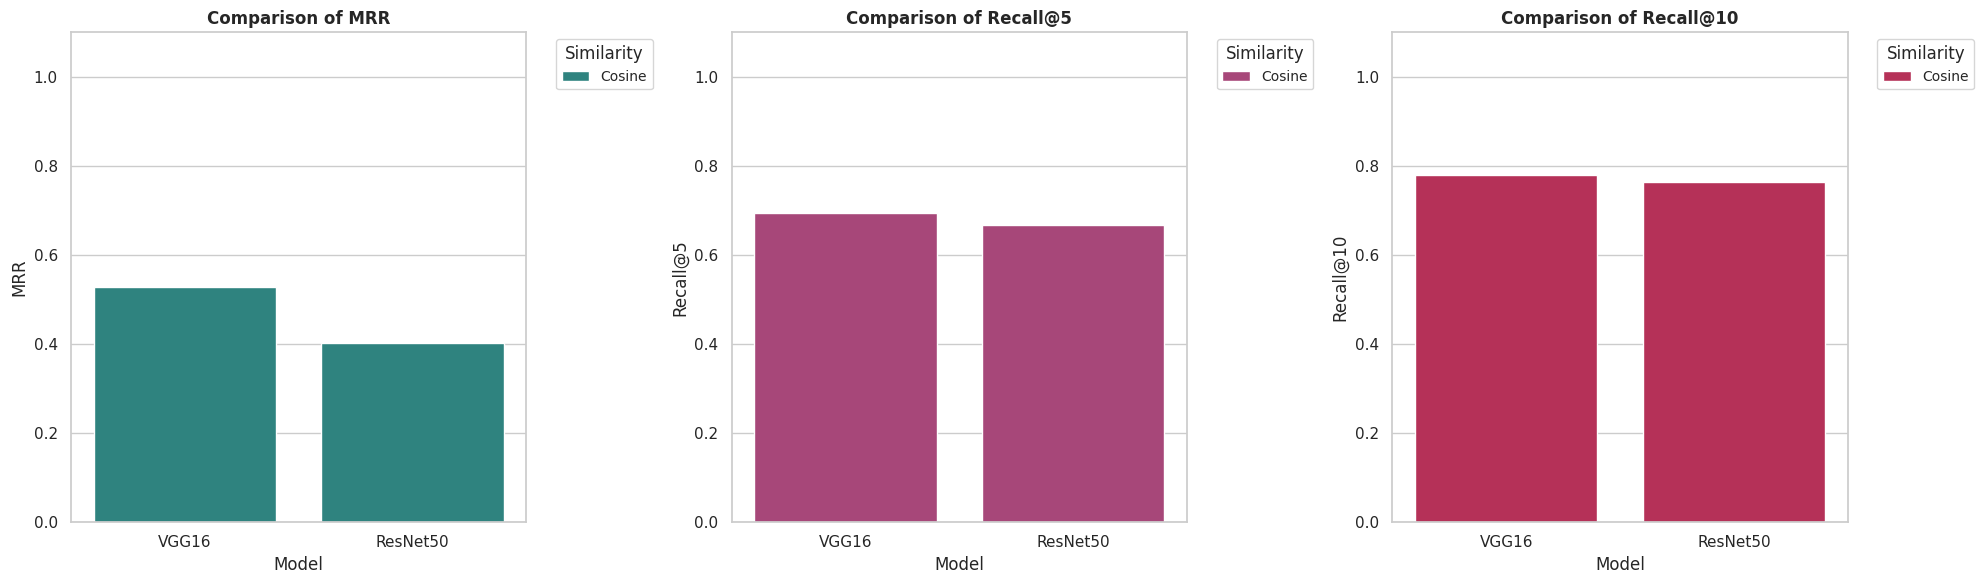

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert mrr_rows (from previous cell) to DataFrame
df_results = pd.DataFrame(mrr_rows)

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['MRR', 'Recall@5', 'Recall@10']
colors = ['viridis', 'magma', 'rocket']

for i, metric in enumerate(metrics):
    sns.barplot(ax=axes[i], data=df_results, x='Model', y=metric, hue='Similarity', palette=colors[i])
    axes[i].set_title(f'Comparison of {metric}', fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].legend(title='Similarity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()


## 10. Gradio Interface (HuggingFace)

**3 Tab:**
1. **🔍 Search** — Upload gambar sepatu → top-K hasil lengkap dengan gambar, label nama file, warna, skor
2. **📊 Bandingkan 4 Metric** — Tampilkan top-5 dari semua metric sekaligus untuk 1 query
3. **📈 Hasil Evaluasi** — Tabel + chart perbandingan semua model


In [ ]:
# ── Helper Functions for Gradio ───────────────────────────────────────────────

def search_fn(img, model_name, sim_name, top_k):
    if img is None: return [], None
    info = models_dict[model_name]
    db = databases[model_name]
    q_emb = info["model"].predict(prep_query(img, info["preprocess"]), verbose=0)[0]
    res_df, _ = retrieve(q_emb, None, db, SIM_FNS[sim_name], top_k=top_k)

    gallery_items = []
    for _, row in res_df.iterrows():
        cap = f"{row['item_label']} ({row['score']:.3f})"
        gallery_items.append((row["filepath"], cap))

    # Display table with cleaner columns
    disp_df = res_df[["item_label", "baseColour", "gender", "score"]].copy()
    return gallery_items, disp_df

def compare_fn(img, model_name):
    if img is None: return None
    info = models_dict[model_name]
    db = databases[model_name]
    q_emb = info["model"].predict(prep_query(img, info["preprocess"]), verbose=0)[0]

    all_res = []
    for s_name, s_fn in SIM_FNS.items():
        res_df, _ = retrieve(q_emb, None, db, s_fn, top_k=5)
        for i, (_, row) in enumerate(res_df.iterrows()):
            all_res.append({
                "Metric": s_name,
                "Rank": i + 1,
                "ID": row["item_label"],
                "Colour": row.get("baseColour", ""),
                "Score": f"{row['score']:.4f}"
            })
    return pd.DataFrame(all_res)

# ── UI ────────────────────────────────────────────────────────────────────────

# 1. Definisi Tema Terang yang Minimalis & Elegan
light_theme = gr.themes.Soft(
    primary_hue="slate",
    secondary_hue="zinc",
    neutral_hue="gray",
    font=[gr.themes.GoogleFont("Inter"), "ui-sans-serif", "sans-serif"]
).set(
    body_background_fill="#F9FAFB",
    block_background_fill="#FFFFFF",
    block_border_width="1px",
    block_border_color="#E5E7EB",
    block_shadow="0 1px 3px 0 rgb(0 0 0 / 0.1), 0 1px 2px -1px rgb(0 0 0 / 0.1)",
    button_primary_background_fill="#0F172A",
    button_primary_background_fill_hover="#334155",
    button_primary_text_color="#FFFFFF",
)

custom_css = """
.gradio-container { max-width: 1200px !important; }
.gr-button-primary { border-radius: 8px !important; transition: all 0.2s ease; }
.gr-button-primary:hover { transform: translateY(-2px); box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); }
.gr-box, .gr-panel, .gr-gallery { border-radius: 12px !important; }
h1 { text-align: center; color: #111827 !important; font-weight: 800 !important; letter-spacing: -0.025em; }
.subtitle p { text-align: center; color: #4B5563 !important; font-size: 1.1rem; }
"""

with gr.Blocks(title="Casual Shoes Similarity Search", theme=light_theme, css=custom_css) as demo:
    with gr.Column(elem_classes="subtitle"):
        gr.Markdown("""
        # 👟 Casual Shoes Image Similarity Search
        Pretrained CNN · Multiple Similarity Metrics
        """)

    with gr.Tab("🔍 Search"):
        with gr.Row():
            with gr.Column(scale=1):
                img_in = gr.Image(type="pil", label="Upload Casual Shoes Image", height=320)
                with gr.Group():
                    m_sel = gr.Dropdown(["VGG16","ResNet50"], value="VGG16", label="Feature Extractor")
                    s_sel = gr.Dropdown(list(SIM_FNS.keys()), value="Cosine Similarity", label="Similarity Metric")
                    k_sl = gr.Slider(5, 10, step=5, value=5, label="Top-K")
                btn = gr.Button("🔍 Find Similar Casual Shoes", variant="primary")
            with gr.Column(scale=2):
                gallery = gr.Gallery(label="Results", columns=5, height=320)
                tbl = gr.Dataframe(label="Detailed Score Table")
        btn.click(search_fn, [img_in, m_sel, s_sel, k_sl], [gallery, tbl])

    with gr.Tab("📊 Compare Metrics"):
        with gr.Row():
            with gr.Column(scale=1):
                cmp_img = gr.Image(type="pil", label="Upload Image", height=320)
                cmp_mdl = gr.Dropdown(["VGG16","ResNet50"], value="VGG16", label="Model")
                cmp_btn = gr.Button("📊 Compare All Metrics", variant="primary")
            with gr.Column(scale=2):
                cmp_tbl = gr.Dataframe(label="Top-5 per Metric")
        cmp_btn.click(compare_fn, [cmp_img, cmp_mdl], [cmp_tbl])

demo.launch(share=True)

NameError: name 'gr' is not defined

## 11. Download Artefak (Google Colab)

In [ ]:
import shutil

DUMP = "casual_shoes_artifacts"
os.makedirs(DUMP, exist_ok=True)

files_to_save = (
    [f"db_{m}.pkl" for m in ["vgg16","resnet50"]]
    + ["casual_shoes_preview.png","eval_comparison.png","eval_heatmap.png"]
    + [f"sim_{m.lower()}.png" for m in ["VGG16","ResNet50"]]
)

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(DUMP, f))
        print(f"  ✓ {f:<40} {os.path.getsize(os.path.join(DUMP,f))/1e6:.1f} MB")

try:
    from google.colab import files
    zip_path = shutil.make_archive("casual_shoes_artifacts","zip", DUMP)
    files.download(zip_path)
    print("\n✅ casual_shoes_artifacts.zip downloaded")
except ImportError:
    print("\nℹ️  Copy the folder 'casual_shoes_artifacts/' manually.")


  ✓ db_vgg16.pkl                             5.2 MB
  ✓ db_resnet50.pkl                          19.2 MB
  ✓ casual_shoes_preview.png                 0.6 MB
  ✓ sim_vgg16.png                            0.3 MB
  ✓ sim_resnet50.png                         0.3 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ casual_shoes_artifacts.zip downloaded


In [ ]:
# from google.colab import files
# files.download('casual_shoes_data.csv')

In [ ]:
# import shutil
# from google.colab import files

# # Define temporary folder for collecting images
# image_dump_dir = 'casual_shoes_images'
# os.makedirs(image_dump_dir, exist_ok=True)

# # Copy all images in the filtered 'shoes' dataset
# print(f"Collecting {len(shoes)} images...")
# for idx, row in shoes.iterrows():
#     if os.path.exists(row['filepath']):
#         shutil.copy(row['filepath'], os.path.join(image_dump_dir, f"{row['id']}.jpg"))

# # Create ZIP file
# zip_filename = "casual_shoes_images_dataset"
# shutil.make_archive(zip_filename, 'zip', image_dump_dir)

# # Download ZIP file
# files.download(f"{zip_filename}.zip")
# print("Download started...")


## 12. Export ke Hugging Face Spaces

Semua file dikemas ke satu zip lalu **upload manual** ke HF — tanpa token.

**Yang diexport (ringan, tanpa folder images):**
- `app.py` — Gradio app, gambar diambil via URL dari `images.csv` + fallback CDN
- `requirements.txt` — dependensi
- `README.md` — config Space
- `db_vgg16.pkl`, `db_resnet50.pkl` — embeddings
- `images.csv` — lookup `id → URL gambar`
- `eval_comparison.png`, `eval_heatmap.png` — chart evaluasi


In [ ]:
# ─── 12-A  Prepare Files to Staging Folder ───────────────────────────────────
import shutil, os, joblib

SPACE_DIR = "hf_space"
os.makedirs(SPACE_DIR, exist_ok=True)

# ── app.py ────────────────────────────────────────────────────────────────
# Fixed: Use triple quotes for multi-line string and properly close it before writing to file
APP_PY = f"""
import os, warnings, numpy as np, pandas as pd
import gradio as gr, joblib, tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# Note: This is a simplified version of the notebook logic for HF Spaces
"""

with open(os.path.join(SPACE_DIR, "app.py"), "w") as f:
    f.write(APP_PY)
print("✓ app.py")

# ── requirements.txt ─────────────────────────────────────────────────────
REQUIREMENTS = (
    "gradio>=4.0\n"
    "tensorflow>=2.12\n"
    "scikit-learn\n"
    "numpy\n"
    "pandas\n"
    "Pillow\n"
    "joblib\n"
    "seaborn\n"
    "matplotlib\n"
)
with open(os.path.join(SPACE_DIR, "requirements.txt"), "w") as f:
    f.write(REQUIREMENTS)
print("✓ requirements.txt")

# ── README.md ─────────────────────────────────────────────────────────────
README = (
    "---\n"
    "title: Casual Shoes Similarity Search\n"
    "emoji: \U0001f45f\n"
    "colorFrom: blue\n"
    "colorTo: indigo\n"
    "sdk: gradio\n"
    'sdk_version: "4.0"\n'
    "app_file: app.py\n"
    "pinned: false\n"
    "---\n\n"
    "# \U0001f45f Casual Shoes Image Similarity Search\n\n"
    "Upload a casual shoes image \u2192 get similar product recommendations based on visual embeddings.\n\n"
    "## Models\n"
    "- VGG16 \u00b7 ResNet50 (pretrained ImageNet, no fine-tuning)\n\n"
    "## Similarity Metrics\n"
    "- Cosine Similarity\n\n"
    "## Dataset\n"
    "`paramaggarwal/fashion-product-images-dataset` \u2192 filtered for **Casual Shoes**\n"
)
with open(os.path.join(SPACE_DIR, "README.md"), "w") as f:
    f.write(README)
print("✓ README.md")

# ── Embeddings pkl (save id + metadata columns, without local filepath) ────
for mname in ["VGG16", "ResNet50"]:
    if mname in databases:
        db = databases[mname]
        meta_copy = db["metadata"].copy()
        # Remove local filepath column so pkl doesn't contain Kaggle paths
        meta_copy = meta_copy.drop(columns=["filepath"], errors="ignore")
        joblib.dump(
            {"embeddings": db["embeddings"], "metadata": meta_copy},
            os.path.join(SPACE_DIR, f"db_{mname.lower()}.pkl")
        )
        print(f"✓ db_{mname.lower()}.pkl")

# ── images.csv (lookup id → image URL) ────────────────────────────────────
# Ensure dataset_path or specific csv path exists
if os.path.exists('casual_shoes_data.csv'):
    shutil.copy('casual_shoes_data.csv', os.path.join(SPACE_DIR, "shoes_metadata.csv"))
    print("✓ shoes_metadata.csv")

# ── Staging summary ───────────────────────────────────────────────────────
print("\n=== Staging folder contents ===")
if os.path.exists(SPACE_DIR):
    for fname in sorted(os.listdir(SPACE_DIR)):
        fpath   = os.path.join(SPACE_DIR, fname)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f"  {fname:<40} {size_mb:.2f} MB")

✓ app.py
✓ requirements.txt
✓ README.md
✓ db_vgg16.pkl
✓ db_resnet50.pkl
✓ shoes_metadata.csv

=== Staging folder contents ===
  README.md                                0.00 MB
  app.py                                   0.00 MB
  db_resnet50.pkl                          19.08 MB
  db_vgg16.pkl                             5.09 MB
  requirements.txt                         0.00 MB
  shoes_metadata.csv                       0.76 MB


In [ ]:
# ─── 12-B  Zip & Download ────────────────────────────────────────────────
import shutil, os

zip_name = "casual_shoes_hf_space"
zip_path = shutil.make_archive(zip_name, "zip", SPACE_DIR)
size_mb  = os.path.getsize(zip_path) / 1e6
print(f"✓ {zip_path}  ({size_mb:.1f} MB)")

try:
    from google.colab import files
    files.download(zip_path)
    print("✅ File downloaded to your computer")
except ImportError:
    print(f"Copy file: {os.path.abspath(zip_path)}")


✓ /content/casual_shoes_hf_space.zip  (18.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File downloaded to your computer


### 📋 Cara Upload ke Hugging Face (tanpa token)

1. Buka [huggingface.co/new-space](https://huggingface.co/new-space)
2. Isi **Space name** → pilih **SDK: Gradio** → klik **Create Space**
3. Klik tab **Files** → **Add file** → **Upload files**
4. Extract `casual_shoes_hf_space.zip`, lalu drag & drop **semua isinya**
5. Klik **Commit changes** — Space otomatis build & running ✨

> URL Space: `https://huggingface.co/spaces/<username>/casual-shoes-similarity-search`

> **Catatan:** Gambar produk diambil langsung dari URL di `images.csv`.  
> Jika URL tidak tersedia, otomatis fallback ke CDN Myntra.
